In [1]:
%reset -f

### Registration using "registrator" - a wrapper for Simple ITK


This demo-notebook explains how to use the "registrator"-wrapper for Simple ITK. The following packages are needed: Simple-ITK, CIL, numpy, os, matplotlib, importlib, plotly, jupytaer notebook (>>> conda install notebook), random and copy. All of these can be installed using pip install or conda install. CIL is only used to load data, and nothing else...

You will need the .py files
"plot_library.py" and "registrator.py"

In the demo we show how to register two volumes: These are x-ray and neutron reconstructions of the black beauty meteorite, slice B. The reconstructions are obtianed using FBP. Both volumes are around 1000³ voxels.

In this demo, the data is normalized to have values between zero and one. After normalization, some characteristics of the data are:
    - X-ray: Background value is around 0.1, intensity values in the meteorite around 0.8. 0.2 is a good threshold value. In the volume, a cylinder around the meteorite is visible. The noise is generally low.
    - Neutron: The background is around 0.4 and meteorite intensity around 0.6. A good threshold value is 0.5. The neutron data is much more noisy. This is why the intensity values get concentrated around 0.5 during the normalizatoin.

Running this demo takes XX minutes with te default options on the HPC (on the default processor on the linuxsh node).


#### Import libraries

In [1]:
from cil.io import ZEISSDataReader
import numpy as np
import os
#current_directory = os.getcwd()
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')  # Navigate into a subdirectory
#print("Current working directory:", current_directory)
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader, TIFFWriter
import plot_library as pl
import SimpleITK as sitk
import importlib
import registrator
import plotly.io as pio
pio.renderers.default = "notebook"
from cil.framework import ImageData, ImageGeometry

#### Define paths for data (change this)

In [2]:
#reconpath0 = "/home/msaca/Data/sliceB_xray_dtu/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath0 = "/dtu-compute/msaca/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"



#reconpath_neutron = "/home/msaca/Data/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"
reconpath_neutron = "/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"

#### Load x-ray data and normalize using the pl module (from plot_library.py)

In [3]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

#### Load neutron data and normalize using the pl module (from plot_library.py)

In [4]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

#### Reload registrator class

(Using .reload(), you can change registrator.py, save the changes and apply them, without having to restart the kernel and reload the data)

In [178]:
importlib.reload(registrator)

<module 'registrator' from '/zhome/71/c/146676/Desktop/msaca/main/registrator.py'>

#### Initialize a Registratior() class object, "reg", and load in data.

The class contains two important members: reg.fixed and reg.moving. These are the two volumes we want to register. These are simpleITK images.

In [179]:
reg = registrator.Registrator()
reg.load_images(fixed_array=recon_neutron, moving_array=recon_xray)
threshold = [0.5, 0.2]
reg.resample(transform_centroid,padding=[0,200,50],fixed =True)

Resampling the transformation: 104105
Resampling fixed image


The Registrator class has 3 methods worth remembering:

.transformation(): 
    - Input: Some options specifying with transformation to create
    - Output: A transformation: A class object in simpleITK
    Description: The goal of this class is to create a custom (user defined transformation)

.register():
    - Input: Options specifying options for the registration
    - Output: A transformation
    Description: The goal of this class is to create a transformation, which (when applied to reg.moving) will register reg.fixed with reg.moving.

.resample():
    - Input: A transformation
    - Output: None (or a simpleITK image)
    Description: Applies a transformation to either reg.moving (default) or reg.fixed () using interpolation.
    If in_place=True, the transformation is applied in place to either reg.moving or reg.fixed (the old volume is overwritten). If in_place=False, the transformed volume is returned

There are two auxilliary methods that are also used:
.apply_mean():
    - Input: A sitk image (for example reg.fixed or reg.moving), and a filter kernel size, "smooth".
    - Output: A sitk image
    Description: Filters the input image with a mean filter with kernel size "smooth"

.plot2d()
    - Input: Threshold values (a list with two elements, thresholding reg.fixed and reg.moving), difference
    - Output: None
    Description: Plots reg.fixed and reg.moving overlayed on each other. if difference=True, the difference in the threholded volumes are plotted. The plot is a slice along the two principal axes of the meteorite. The slice with the largest mass is chosen. The thresholding values are very important.




#### Get centroid transformation and apply

This transformation places the two images in te same coordinate system, and aligns the centroids of the images.

In [180]:
transform_centroid = reg.transformation(type='Centroid')
reg.resample(transform_centroid)

Resampling the transformation: 374258
Resampling moving image


#### Plot the resulting volumes

278 197


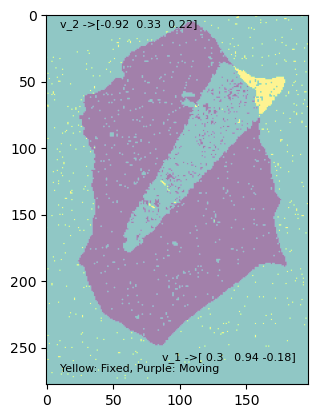

In [181]:
reg.plot2d(thresholds = threshold,difference=True,moving=True)

#### Rotate the volume around the zero'th axis and plot

By trial and error, I found that applying registration without flipping the reg.moving volume, resulted in a local minima in the registration, where the meteorite had been flipped. Here you can see how to define a transformation matrix and apply it...

Resampling the transformation: 40107
Resampling moving image
278 197


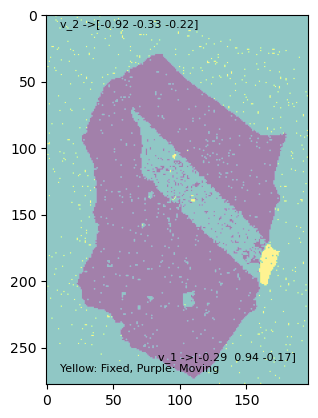

In [182]:
angle_radians = np.deg2rad(180)
rotation_matrix = [
                [1, 0, 0],
                [0, np.cos(angle_radians), -np.sin(angle_radians)],
                [0, np.sin(angle_radians), np.cos(angle_radians)]
            ]
matrix = [elem for row in rotation_matrix for elem in row]
transform_flip = reg.transformation(type='Similarity3DTransform', matrix=matrix, translation=(0,0,0))
reg.resample(transform_flip)
reg.plot2d(thresholds = threshold,difference=True,moving=True)

#### Precompute smoothed versions of the neutron image (reg.moving)

This precomputed some smoothed images and saves them in a dictionary. This is used in the registration to speed it up. If smooting is specified during registration, the smoothing is calculated on the fly. Calculating the smoothed images in advance trades memory for speed. (Higher speed if calculated in advance, but higher memory usage). 

In [183]:

reg.fixed_smooth['2'] = reg.apply_mean(reg.fixed, smooth=2)

#### Do first registration loop

The following settings are set:

Learning rate: 10 (this is relatively high. Start with a high value and lower it for the next loops). The learning rate is the step size in the optimization algorithm.

Sampling percentage: The percentage of pixels used in the volume for calculaing the loss function of the registration. Minimum 0, maximum 1. The computation time scales linearly with the sampling percentage.

max_iter: Numer of iterations in the optimization loop.

metric_type: 'ms'/'ls' or 'mmi'. Specifying 'ms' or 'ls' used mean squares as the loss function. As the intensity values differ in the images, a threshold is used on both images to determine what is stone and what is not. Currently only the mean squares loss works for this example. mmi is the mattes mutual information.

optimizer type: 'gd' Currently only gd=gradient descent is supported.

smoothing: Apply smoothing to either reg.fixed or reg.moving. Set to smoothing=0 to apply no smoothing. Set to smoothing=2 , 3 , 4 , 5 to apply smoothing with these kernel sizes. In order to use reg.moving_smooth['N'] or reg.fixed_smooth['N'], set smoothing = N, where N is 2,3,4,5...

smooth_fixed, smooth_moving: True or False, set to true to apply smoothing, false if not.

Shrinking: Shrinks the image by shrinking in each dimension. This greatly reduces the computaion time by a factor of shrinking³. 

thresholds: The threshold values used in the least squares

Using precalculated smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 0.3300416 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.04620836319885141
The current learning rate is 10.0
Iteration 20: Metric Value = 0.0413050024481994, Metric Difference = 0.004903360750652008
The current learning rate is 10.0
Iteration 40: Metric Value = 0.03043462238482332, Metric Difference = 0.010870380063376081
The current learning rate is 10.0
Iteration 60: Metric Value = 0.02654582888166951, Metric Difference = 0.0038887935031538118
The current learning rate is 10.0
Iteration 80: Metric Value = 0.027551862011964134, Metric Difference = 0.0010060331302946257
The current learning rate is 10.0
Iteration 100: Metric Value = 0.028074003269566012, Metric Difference = 0.0005221412576018776
The current learning rate is 10.0
Iteration 120: Metric Value = 0.028369978111480527, Metric Difference =

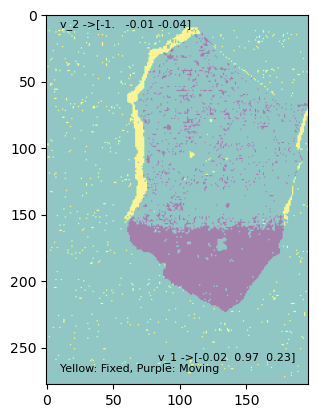

In [184]:
transform_registration= reg.register(learning_rate = 10, sampling_percentage = 0.5, max_iter = 200,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 2, shrinking = 7, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True,moving=True)

#### Do registration with smaller learning rate, smaller sampling percentage, less smooting, and less shrinking

Using precalculated smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 0.1359306 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.015849775400765098, Metric Difference = 0.01259231865257409
The current learning rate is 1.0
Iteration 5: Metric Value = 0.008727211883459492, Metric Difference = 0.0071225635173056065
The current learning rate is 1.0
Iteration 10: Metric Value = 0.006505885578413465, Metric Difference = 0.0022213263050460267
The current learning rate is 1.0
Iteration 15: Metric Value = 0.0061329413465387676, Metric Difference = 0.00037294423187469745
The current learning rate is 1.0
Iteration 20: Metric Value = 0.00596513230614201, Metric Difference = 0.00016780904039675765
The current learning rate is 1.0
Iteration 25: Metric Value = 0.005833626704329467, Metric Difference = 0.00013150560181254302
The current learning rate is 1.0
Iteration 30: Metric Value =

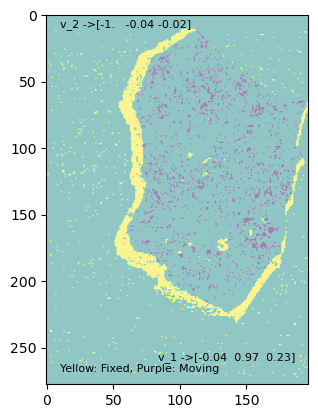

In [185]:
transform_registration= reg.register(learning_rate = 1, sampling_percentage = 0.3, max_iter = 50,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 2, shrinking = 5, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True,moving=True)

#### Do registration with smaller learning rate, smaller sampling percentage, less smooting, and less shrinking

Using non-smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 0.42250469333333335 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.028242600502511744, Metric Difference = 0.022789498303117845
The current learning rate is 0.5
Iteration 10: Metric Value = 0.02821839056410564, Metric Difference = 2.4209938406103554e-05
The current learning rate is 0.5
Iteration 20: Metric Value = 0.028191848453902883, Metric Difference = 2.654211020275757e-05
The current learning rate is 0.5
Iteration 30: Metric Value = 0.028164030975163963, Metric Difference = 2.781747873891946e-05
The current learning rate is 0.5
Iteration 40: Metric Value = 0.028136544620016617, Metric Difference = 2.7486355147345737e-05
The current learning rate is 0.5
Iteration 50: Metric Value = 0.02811006263372492, Metric Difference = 2.6481986291695958e-05
The current learning rate is 0.5
Iteration 60: Metric Value =

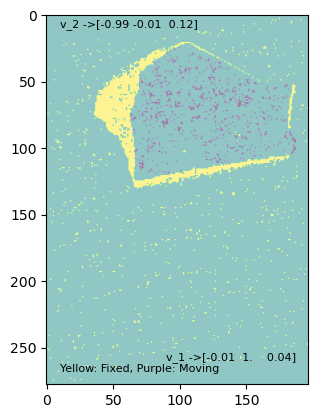

In [ ]:
transform_registration= reg.register(learning_rate = 0.5, sampling_percentage = 0.1, max_iter = 100,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 0, shrinking = 3, thresholds=threshold,
                                        smooth_fixed = False, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True, moving=True)

#### Do registration with smaller learning rate, smaller sampling percentage, less smooting, and less shrinking

#### A plot of the non-thresholded attenuation values

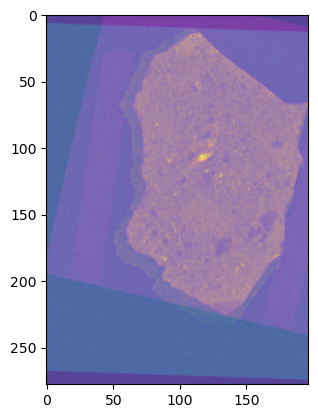

In [187]:
reg.plot2d(thresholds = threshold, difference=False, moving=True)

#### We are satisfied with the registration. What can we do now?

0. Apply rescaling and compress the data to uint16 to save disc space.

1. We can save the result directly. (for example as tiff-files). If this is done, you only need to save reg.moving.

2. Transform both reg.fixed and reg.moving usin the same transformation. This transformation could for exmaple align the principal axes of the meteorite with the coordinate axes. If this is done, data can be compress to around 100 slices (depending on the thickness of the meteorite. If this is done, you need to save both reg.moving and reg.fixed)

3. Save the following metadata: The input and output folder of where the files are read/written. The parameters of the transformation applied (all transformations can be composed into one transformation with only 12 (7) parameters. 3 translation paramters and 9 matrix parameters. By restricting to transformations that preserve angles and scales each dimension equally much, the matrix only has 4 parameters, 3 rotation and one scaling).

4. Do further analysis in simpleITK with the images, fx segmentation.

 We now display how to do 1 and 2. We also show some more plots of the registered volumes.

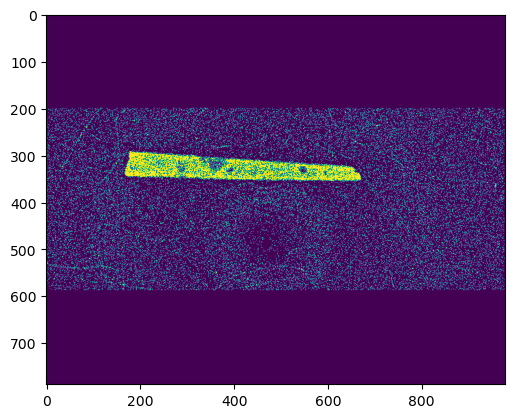

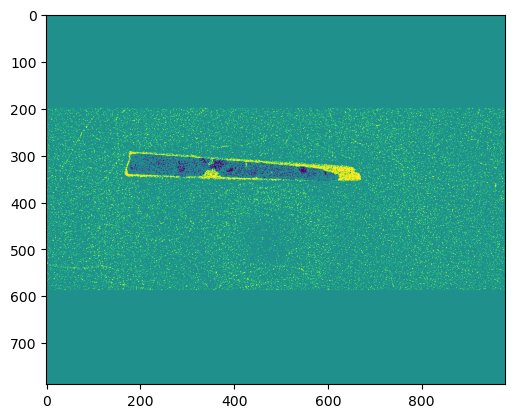

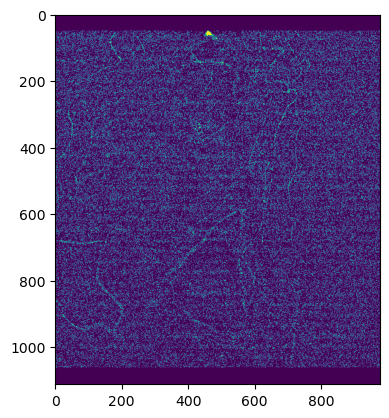

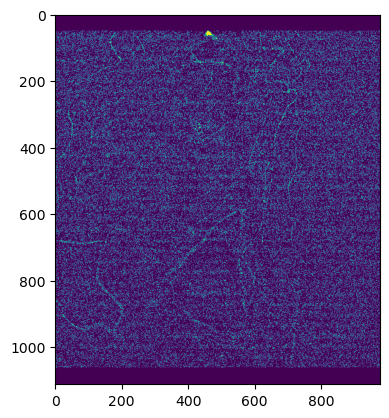

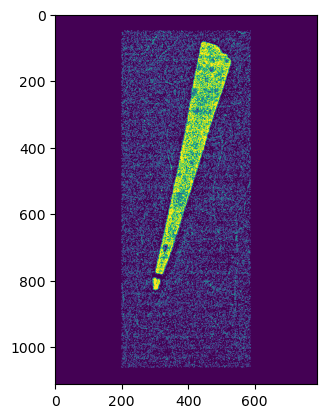

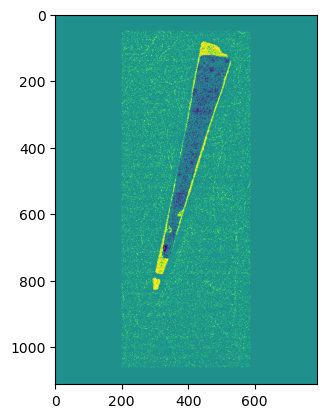

In [188]:
N_slice = 700
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[N_slice,:,:]>threshold[1]))
plt.show()

N_slice = 550
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,N_slice,:]>threshold[1]))
plt.show()

N_slice = 550
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,:,N_slice]>threshold[1]))
plt.show()

#### Plotting revealed that the image is flipped! Just look at the second plot. Let us fix this

Align principal axes of the moving image with coordinate axis

In [189]:
transform_principal_fixed = reg.transformation(type='Principal', thresholds = threshold, principal_inverse=False, principal_fixed=True)
reg.resample(transform_principal_fixed)

Resampling the transformation: 17019
Resampling moving image


flip along the principal axis

In [190]:
rotation_matrix = [
                [-1, 0, 0],
                [0, 1, 0],
                [0, 0, 1]
            ]
matrix = [elem for row in rotation_matrix for elem in row]
transform_mirror= reg.transformation(type='Affine', matrix=matrix, translation=(0,0,0))
reg.resample(transform_mirror)

Resampling the transformation: 726271
Resampling moving image


apply the inverse principal axes transformation

In [191]:
transform_principal_fixed_inverse = reg.transformation(type='Principal', thresholds = threshold, principal_inverse=True, principal_fixed=True)
reg.resample(transform_principal_fixed_inverse)


Resampling the transformation: 684169
Resampling moving image


Plot the images

[0.5, 0.2]


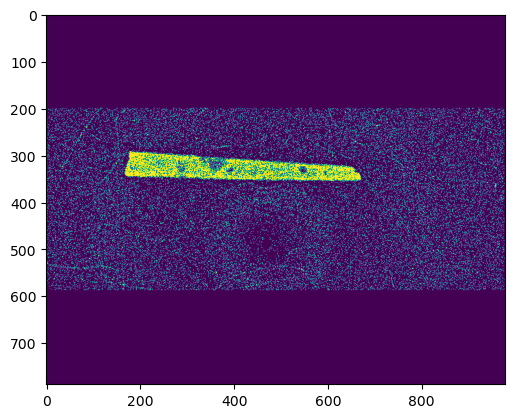

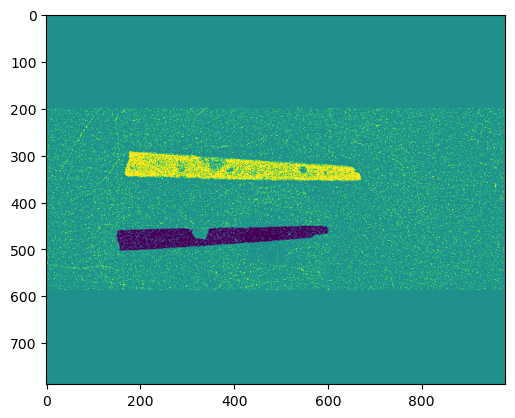

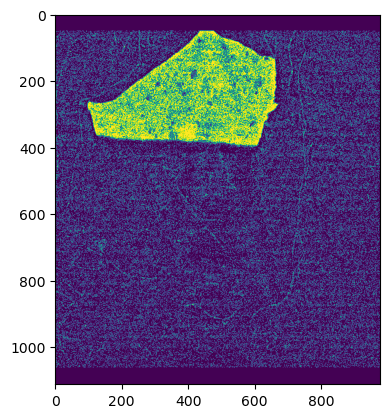

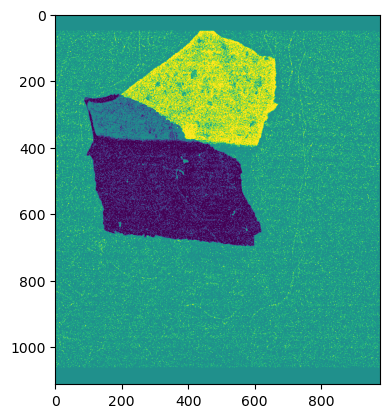

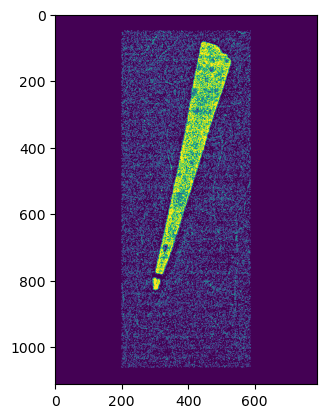

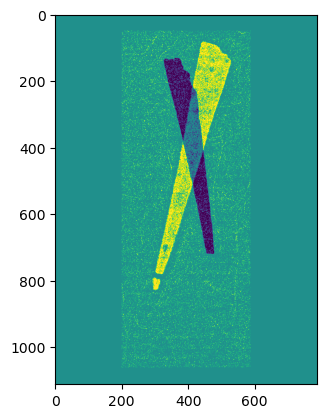

In [199]:
print(threshold)
N_slice = 700
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[N_slice,:,:]>threshold[1]))
plt.show()

N_slice = 450
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,N_slice,:]>threshold[1]))
plt.show()

N_slice = 550
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,:,N_slice]>threshold[1]))
plt.show()

This looks better, but a re-registration is needed:

Using precalculated smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 1.359306 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.019515161424049885, Metric Difference = 0.007217253712524397
The current learning rate is 3.0
Iteration 50: Metric Value = 0.010316309993955964, Metric Difference = 0.009198851430093921
The current learning rate is 3.0
Iteration 100: Metric Value = 0.004982795522607182, Metric Difference = 0.005333514471348781
The current learning rate is 3.0
Iteration 150: Metric Value = 0.002463543832982905, Metric Difference = 0.002519251689624277
The current learning rate is 3.0
Iteration 200: Metric Value = 0.0011403350837225202, Metric Difference = 0.001323208749260385
The current learning rate is 3.0
Iteration 250: Metric Value = 0.0008973373104193802, Metric Difference = 0.00024299777330313995
The current learning rate is 3.0
Iteration 300: Metric Value

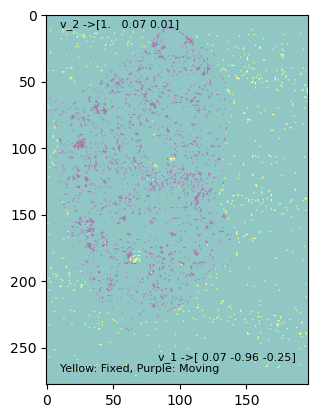

In [201]:
transform_registration= reg.register(learning_rate = 3, sampling_percentage = 0.3, max_iter = 500,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 2, shrinking = 5, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True,moving=True)

Calculating smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 0.8450093866666667 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.024540958907307724, Metric Difference = 2.8170303875165587e-05
The current learning rate is 0.1
Iteration 10: Metric Value = 0.024540927067973943, Metric Difference = 3.183933378059223e-08
The current learning rate is 0.1
Iteration 20: Metric Value = 0.024540862717867002, Metric Difference = 6.435010694097465e-08
The current learning rate is 0.1
Iteration 30: Metric Value = 0.02454076845943842, Metric Difference = 9.425842858318267e-08
The current learning rate is 0.1
Iteration 40: Metric Value = 0.02454071596317508, Metric Difference = 5.249626333983515e-08
The current learning rate is 0.1
Iteration 50: Metric Value = 0.024540651941993227, Metric Difference = 6.402118185241945e-08
The current learning rate is 0.1
Iteration 60: Metric Value =

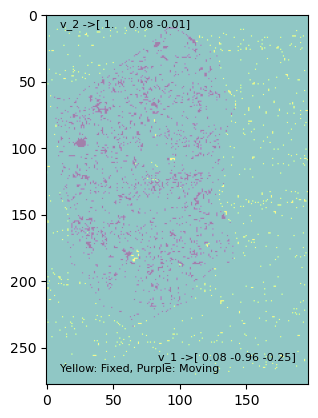

In [203]:
transform_registration= reg.register(learning_rate = 0.1, sampling_percentage = 0.2, max_iter = 100,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 0, shrinking = 3, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True, moving=True)

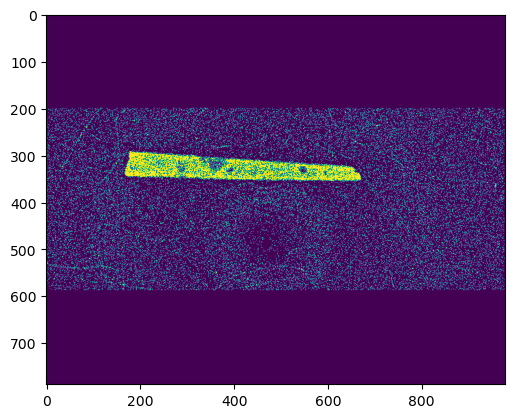

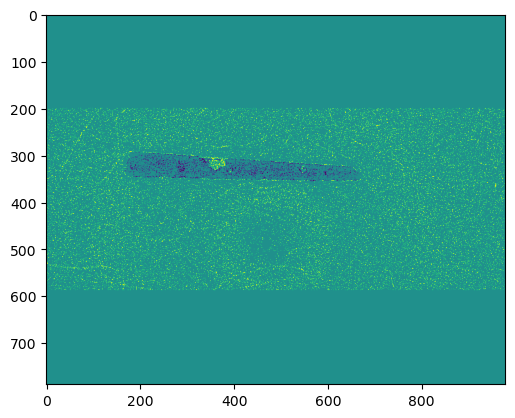

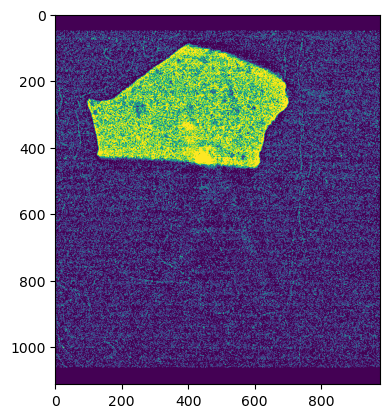

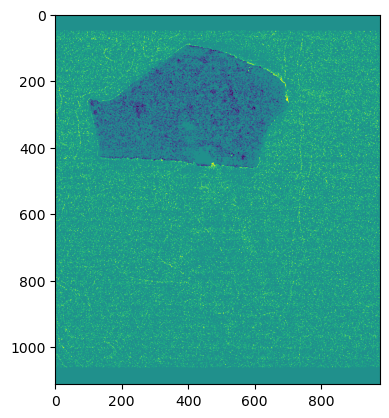

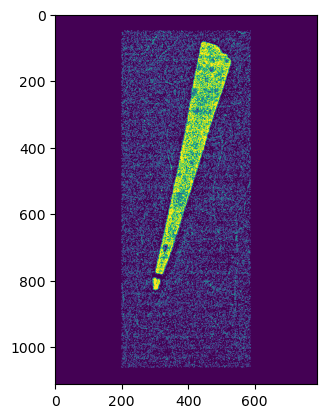

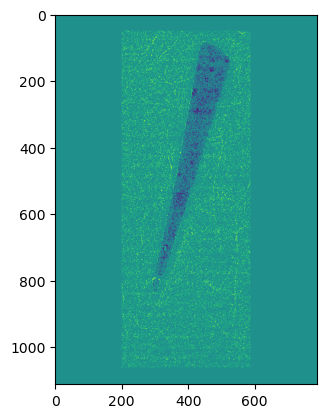

In [205]:
N_slice = 700
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[N_slice,:,:]>threshold[1]))
plt.show()

N_slice = 430
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,N_slice,:]>threshold[1]))
plt.show()

N_slice = 550
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,:,N_slice]>threshold[1]))
plt.show()

#### Saving the (xray) data

In [ ]:
xray_data = GetArrayFromImage(reg.moving)[:,200:-200,50:-50]
n1,n2,n3 = np.shape(xray_data)
ig = ImageGeometry(voxel_num_x=n1, voxel_num_y=n2, voxel_num_z=n3)

In [ ]:
xray_data = ImageData(sitk.GetArrayFromImage(reg.moving), geometry=ig)
writer = TIFFWriter(data=xray_data, file_name='/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_registered/registered_to_neutron/',
counter_offset=0, compression=None)
writer.write()

Rotate both datasets and crop...:

In [ ]:
transform_principal_fixed = reg.transformation(type='Principal', thresholds = [0.2, 0.5], principal_inverse=False, principal_fixed=True)
reg.resample(transform_principal_fixed)

Resampling the transformation: 866156
Resampling moving image
Resampling smoothed moving images
Method already called with ID: 866156


In [40]:
transform_principal_fixed.ID = 32908
reg.resample(transform_principal_fixed,fixed=True)

Resampling the transformation: 32908
Resampling fixed image


In [67]:
N_slice_start = 400
N_slice_end = 540
# In order to make this choise of cropping, i plotted the meteorite...
xray_data = sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice_start : N_slice_end]
neutron_data = sitk.GetArrayFromImage(reg.moving)[:,:,N_slice_start : N_slice_end]

In [ ]:
N = np.shape(xray_data)
ig = ImageGeometry(voxel_num_x=N[0], voxel_num_y=N[1], voxel_num_z=N[2])
xray_data2 = ImageData(np.transpose(xray_data,(2,1,0)), geometry=ig)
writer = TIFFWriter(data=xray_data2, file_name='/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_registered/rotated/sliceB_xray_rotated',
counter_offset=0, compression=None)
#writer.write()

In [71]:
neutron_data2 = ImageData(np.transpose(neutron_data,(2,1,0)), geometry=ig)
writer = TIFFWriter(data=neutron_data2, file_name='/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_registered_rotated/sliceB_neutron_registered_rotated',
counter_offset=0, compression=None)
writer.write()

#### Some details that are nice to know:

Transformations returned by .transformation() and .register() have an attribute called .FLAG. It can be accessed by transform.FLAG. .resample() checks if .FLAG is True, and if that is the case, the resampling is not carried out. .register sets transform.FLAG = True of the loss function value at the end of an optimization loop is higher than at the beginning. To carry out the resampling anyway, you can simply overwrite this by setting transform.FLAG = False.

Each transformatoin also has a unique ID. Transformations with the same ID cannot be used .resample more than once. You can access the sequence of transformations used in .resample by printing reg.called_inputs

The class Registrator has an attribute/member called .callback.
reg.callback is initialized to 1, which ensures that informatio nabout the optimization is printed out. Callback can be set to zero, to disable this. But currently the .FLAG requires that callback is set to 1.